In [2]:
import pickle
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')
import sys
sys.path.append('/content/drive/MyDrive/LDMX_GNN/GAIN')

Mounted at /content/drive


# GNN Model Comparison — Signal 1.0 GeV A'
Loads pre-saved results for GAIN, IN and CKF. Plots tracking efficiency vs truth recoil momentum, alongside the best possible efficiency.



## Load saved data

In [6]:
with open(os.path.expanduser("/content/drive/MyDrive/LDMX_GNN/results/IN_amb_signal_1pt0GeV_plot_data.pkl"), "rb") as f:
    d_in = pickle.load(f)


with open(os.path.expanduser("/content/drive/MyDrive/LDMX_GNN/results/GAIN_amb_signal_1pt0GeV_plot_data.pkl"), "rb") as f:
    d_gain = pickle.load(f)

# CKF baseline and best possible are the same for both models (same test data)
df_ckf = pd.read_csv(d_gain["ckf_csv"])

## Combined plot

/tmp/ipykernel_13758/3383442766.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


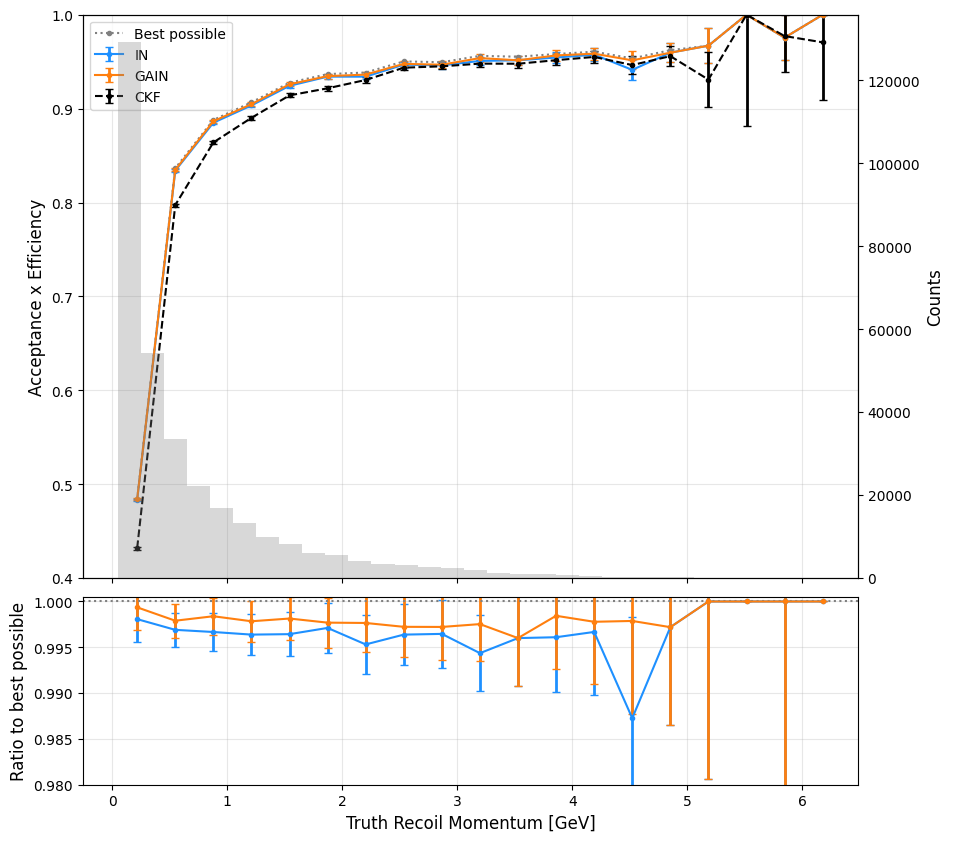

In [7]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05})

# --- Top panel: Acceptance x Efficiency ---

# IN
ax1.errorbar(d_in["P_centers"], d_in["Track_effs"], yerr=d_in["Track_eff_errs"],
             color="dodgerblue", fmt="-o", markersize=3,
             capsize=3, capthick=1, elinewidth=2, label="IN")

# GAIN
ax1.errorbar(d_gain["P_centers"], d_gain["Track_effs"], yerr=d_gain["Track_eff_errs"],
             color="tab:orange", fmt="-o", markersize=3,
             capsize=3, capthick=1, elinewidth=2, label="GAIN")

# CKF baseline
ax1.errorbar(df_ckf.momentum_center, df_ckf.acc_times_eff, yerr=df_ckf.error_low,
             color="black", fmt="--o", markersize=3,
             capsize=3, capthick=1, elinewidth=2, label="CKF")

# Best possible
ax1.plot(d_in["P_centers"], d_in["best_effs"],
         color="gray", linestyle=":", marker="o", markersize=3, label="Best possible")

ax1.set_ylabel("Acceptance x Efficiency", fontsize=12)
ax1.set_ylim(0.4, 1.0)
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10)

# Truth momentum histogram on secondary axis
ax1b = ax1.twinx()
ax1b.hist(d_in["TruthP"], bins=30, alpha=0.3, color="gray")
ax1b.set_ylabel("Counts", fontsize=12)

# --- Bottom panel: Ratio to best possible ---

best = np.array(d_in["best_effs"])
p_centers = np.array(d_in["P_centers"])

# Interpolate CKF onto GNN bin centers
ckf_interp = np.interp(p_centers, df_ckf.momentum_center, df_ckf.acc_times_eff)
ckf_err_interp = np.interp(p_centers, df_ckf.momentum_center, df_ckf.error_low)

in_ratio = np.array(d_in["Track_effs"]) / best
gain_ratio = np.array(d_gain["Track_effs"]) / best
ckf_ratio = ckf_interp / best

in_ratio_err = np.array(d_in["Track_eff_errs"]) / best
gain_ratio_err = np.array(d_gain["Track_eff_errs"]) / best
ckf_ratio_err = ckf_err_interp / best

ax2.errorbar(p_centers, in_ratio, yerr=in_ratio_err,
             color="dodgerblue", fmt="-o", markersize=3,
             capsize=3, capthick=1, elinewidth=2, label="IN")
ax2.errorbar(p_centers, gain_ratio, yerr=gain_ratio_err,
             color="tab:orange", fmt="-o", markersize=3,
             capsize=3, capthick=1, elinewidth=2, label="GAIN")
# ax2.errorbar(p_centers, ckf_ratio, yerr=ckf_ratio_err,
#              color="black", fmt="--o", markersize=3,
#              capsize=3, capthick=1, elinewidth=2, label="CKF")
ax2.axhline(1.0, color="gray", linestyle=":", linewidth=1.5)

#ax2.set_yscale("log")
ax2.set_ylim(0.98, 1.0005)
ax2.set_xlabel("Truth Recoil Momentum [GeV]", fontsize=12)
ax2.set_ylabel("Ratio to best possible", fontsize=12)
ax2.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

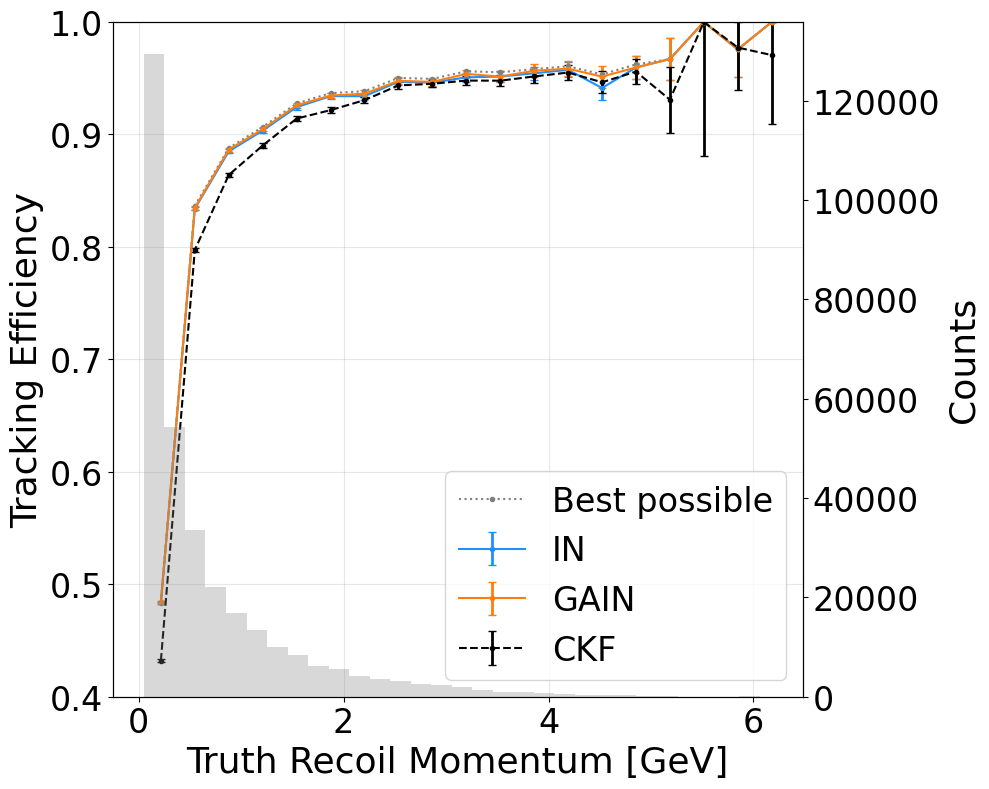

In [9]:
fig, ax1 = plt.subplots(figsize=(10, 8))

# IN
ax1.errorbar(d_in["P_centers"], d_in["Track_effs"], yerr=d_in["Track_eff_errs"],
             color="dodgerblue", fmt="-o", markersize=3,
             capsize=3, capthick=1, elinewidth=2, label="IN")

# GAIN
ax1.errorbar(d_gain["P_centers"], d_gain["Track_effs"], yerr=d_gain["Track_eff_errs"],
             color="tab:orange", fmt="-o", markersize=3,
             capsize=3, capthick=1, elinewidth=2, label="GAIN")

# CKF baseline
ax1.errorbar(df_ckf.momentum_center, df_ckf.acc_times_eff, yerr=df_ckf.error_low,
             color="black", fmt="--o", markersize=3,
             capsize=3, capthick=1, elinewidth=2, label="CKF")

# Best possible
ax1.plot(d_in["P_centers"], d_in["best_effs"],
         color="gray", linestyle=":", marker="o", markersize=3, label="Best possible")

ax1.set_xlabel("Truth Recoil Momentum [GeV]", fontsize=26)
ax1.set_ylabel("Tracking Efficiency", fontsize=26)
ax1.set_ylim(0.4, 1.0)
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=24 , loc="lower right")
ax1.tick_params(labelsize=24)

# Truth momentum histogram on secondary axis
ax1b = ax1.twinx()
ax1b.hist(d_in["TruthP"], bins=30, alpha=0.3, color="gray")
ax1b.set_ylabel("Counts", fontsize=26)
ax1b.tick_params(labelsize=24)


plt.tight_layout()
plt.savefig('/content/drive/MyDrive/LDMX_GNN/figures/fig2.pdf')
plt.show()

# GNN Model Comparison — Multi-electron tagger fake rates 1.0 GeV A'
Loads pre-saved results for GAIN and CKF fake rates, plot comparison.


In [11]:
save_dir = '/content/drive/MyDrive/LDMX_GNN/results/'

df_GAIN2 = pd.read_csv(save_dir + 'GAIN_amb_large_5L_results.csv')
df_CKF  = pd.read_csv(save_dir + 'CKF_tagger_results.csv')

In [12]:
def compute_fake_rates(df, n_prim_col='Num_primaries', n_tracks_col='n_tracks', n_matched_col='n_matched', n_max=5):
    fake_rates = []
    for n in np.arange(n_max) + 1:
        df_cut = df.loc[df[n_prim_col] == n]
        fake_rates.append(np.sum(df_cut[n_tracks_col] - df_cut[n_matched_col]) / len(df_cut))
    return fake_rates

n_primaries_vals = np.arange(5) + 1


fake_rates_GAIN2 = compute_fake_rates(df_GAIN2)
fake_rates_CKF  = compute_fake_rates(df_CKF)

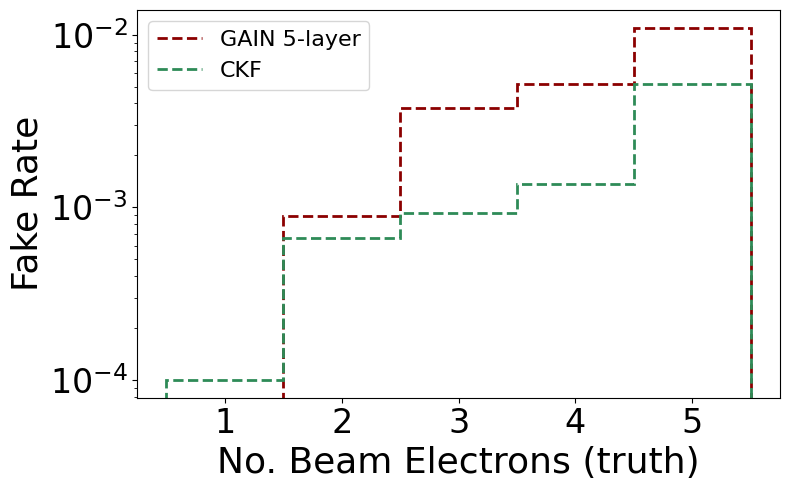

In [13]:
edges = np.arange(6) + 0.5  # bin edges: [0.5, 1.5, 2.5, 3.5, 4.5, 5.5]

fig, ax = plt.subplots(figsize=(8, 5))

ax.stairs(fake_rates_GAIN2, edges, label='GAIN 5-layer', color='darkred', ls = '--', linewidth=2)
ax.stairs(fake_rates_CKF,  edges, label='CKF',  color='seagreen',   ls = '--', linewidth=2)

ax.set_yscale('log')
ax.set_xlabel('No. Beam Electrons (truth)', fontsize=26)
ax.set_ylabel('Fake Rate', fontsize=26)
ax.set_xticks(n_primaries_vals)
ax.tick_params(labelsize=24)

#ax.legend(fontsize=23)
ax.legend(fontsize=16)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/LDMX_GNN/figures/fig3c.pdf')
plt.show()